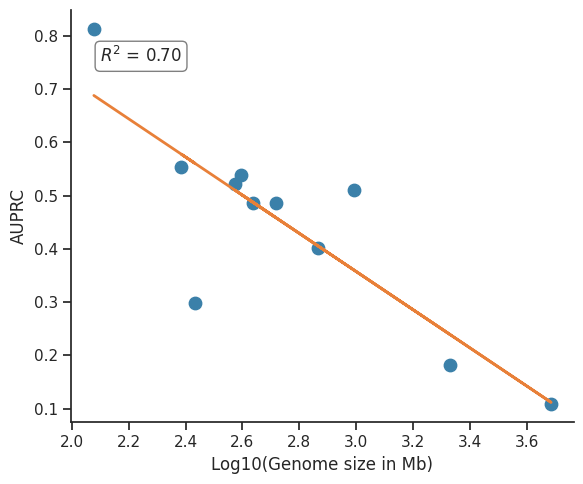

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from scipy.stats import linregress

data = {
    "Genome size": [
        119.66775, 271.163419, 243.117811, 978.495272, 4834.43268,
        374.47124, 521.076998, 434.134862, 394.903069, 732.152042, 2135.083061
    ],
    "AUPRC": [
        0.813053176, 0.297675752, 0.553872974, 0.511135507, 0.109731599,
        0.522064503, 0.485395396, 0.486355738, 0.53790187, 0.401500701, 0.18221516
    ]
}
df = pd.DataFrame(data)
df["log_genome_size"] = np.log10(df["Genome size"])

slope, intercept, r_value, _, _ = linregress(df["log_genome_size"], df["AUPRC"])

plt.figure(figsize=(6, 5))
sns.set(style="ticks")

plt.scatter(df["log_genome_size"], df["AUPRC"], color="#3b80a9", s=80)
plt.plot(df["log_genome_size"], intercept + slope * df["log_genome_size"], color="#e88039", linewidth=2)

plt.text(
    2.1, 0.75, f"$R^2$ = {r_value**2:.2f}", fontsize=12,
    bbox=dict(facecolor='white', edgecolor='gray', boxstyle='round,pad=0.3')
)

plt.xlabel("Log10(Genome size in Mb)", fontsize=12)
plt.ylabel("AUPRC", fontsize=12)
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)

sns.despine(top=True, right=True)
plt.grid(False)
plt.tight_layout()
plt.savefig('genome_size_versus_AUPRC.pdf', format='pdf', bbox_inches='tight')
plt.show()